In [2]:
from heapq import merge
from itertools import count

import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
# import ace_tools as tools 
import torch.nn.functional as F
from imblearn.over_sampling import SMOTE

Load Clean Dataset

In [26]:
data = pd.read_csv('../data/final_data_cleaned.csv')

In [27]:
data

,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,zip_code,dti,delinq_2yrs,...,job_category_executive_owner,job_category_finance,job_category_mechanical_engineering,job_category_medical,job_category_nursing,job_category_other,job_category_other_engineering,job_category_sales,job_category_software_it,job_category_supervisor
0,0.050633,2500,36,0.321262,84.92,10,55000.0,109,0.01924,0.0,...,False,False,False,False,False,True,False,False,False,False
1,0.746835,30000,60,0.530763,777.23,10,90000.0,713,0.02752,0.0,...,False,False,False,False,False,True,False,False,False,False
2,0.113924,5000,36,0.492991,180.69,6,59280.0,490,0.01151,0.0,...,False,False,False,False,False,False,False,False,False,False
3,0.088608,4000,36,0.530763,146.51,10,92000.0,985,0.01774,0.0,...,False,False,False,False,False,True,False,False,False,False
4,0.746835,30000,60,0.421729,731.78,10,57250.0,212,0.02735,0.0,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,0.291139,12000,60,0.341511,279.72,10,58000.0,54,0.02188,0.0,...,False,False,False,False,False,True,False,False,False,False
2260664,0.291139,12000,60,0.798676,358.01,0,30000.0,971,0.02028,3.0,...,False,False,False,False,False,True,False,False,False,False
2260665,0.240506,10000,36,0.260125,332.10,10,64000.0,603,0.01396,0.0,...,False,False,False,False,False,True,False,False,False,False
2260666,0.291139,12000,60,0.628505,327.69,10,60000.0,996,0.03182,2.0,...,False,False,False,False,False,True,False,False,False,False


In [28]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(data)

# Predict anomalies (-1 = anomaly, 1 = normal)
data["fraud_prediction"] = iso_forest.predict(data)

# Convert predictions to binary (1 = fraud, 0 = normal)
data["fraud_prediction"] = data["fraud_prediction"].apply(lambda x: 1 if x == -1 else 0)

C:\Users\mingx\AppData\Local\Temp\ipykernel_6028\4116068619.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=["blue", "red"])


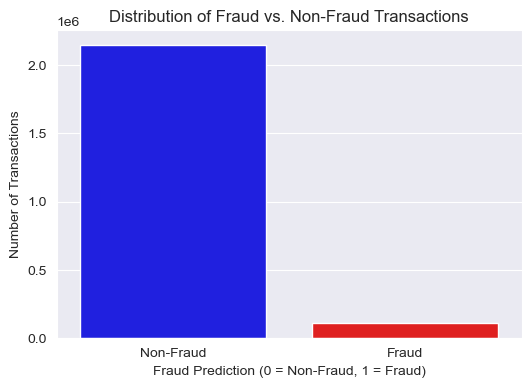

In [29]:
fraud_counts = data["fraud_prediction"].value_counts()

# Plot bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=["blue", "red"])
plt.xlabel("Fraud Prediction (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Fraud vs. Non-Fraud Transactions")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])

# Save image
plt.savefig("../images/fraud_distribution.png")  # Saves the image in the 'images' folder
plt.show()

In [30]:
loan_stacking = data.groupby(["zip_code", "loan_amnt", "last_pymnt_d"]).size().reset_index(name="loan_count")

# Merge back into dataset
data = data.merge(loan_stacking, on=["zip_code", "loan_amnt"], how="left")

# Flag loan stacking fraud (If more than 2 loans with the same amount in the same area)
data["loan_stacking_fraud"] = data["loan_count"].apply(lambda x: 1 if x > 2 else 0)

# Drop temporary `loan_count` column (optional)
data.drop(columns=["loan_count"], inplace=True)

In [7]:
loan_stacking_fraud_cases = data[data["loan_stacking_fraud"] == 1]

# Select a sample of 10 fraud cases
sample_loan_stacking = loan_stacking_fraud_cases[["zip_code", "loan_amnt", "loan_stacking_fraud"]]

# Display table
sample_loan_stacking

,zip_code,loan_amnt,loan_stacking_fraud
0,109,0.050633,1
1,713,0.746835,1
2,490,0.113924,1
3,985,0.088608,1
4,212,0.746835,1
...,...,...,...
2260663,54,0.291139,1
2260664,971,0.291139,1
2260665,603,0.240506,1
2260666,996,0.291139,1


In [37]:
count_fraud = (data["loan_stacking_fraud"] == 0).sum()
print(count_fraud)


265067


In [8]:
data["zip_prefix"] = data["zip_code"].astype(str).str[:3]

# Create a list of state abbreviations (Already One-Hot Encoded)
state_columns = [col for col in data.columns if "addr_state_" in col]

# Check if the ZIP prefix belongs to a mismatched state
data["geo_fraud"] = (data[state_columns].sum(axis=1) == 0).astype(int)  # Flag if no matching state found

# Drop the temporary `zip_prefix` column
data.drop(columns=["zip_prefix"], inplace=True)

In [9]:
stacking_fraud = data.sample(1000).copy()
stacking_fraud["last_pymnt_d"] = np.random.randint(200712, 201902, stacking_fraud.shape[0])
stacking_fraud["loan_amnt"] *= np.random.uniform(0, 1, stacking_fraud.shape[0])
stacking_fraud["fraud_prediction"] = 1  # Mark as fraud

# Create synthetic geographical fraud data
geo_fraud = data.sample(1000).copy()

# Select random ZIP codes from actual dataset
geo_fraud["zip_code"] = np.random.choice(data["zip_code"].unique(), geo_fraud.shape[0])

# Select random states using One-Hot Encoded `addr_state`
geo_fraud_state_columns = [col for col in data.columns if "addr_state_" in col]

# Randomly assign fraudulent locations to One-Hot Encoded states
for col in geo_fraud_state_columns:
    geo_fraud[col] = np.random.choice([0, 1], geo_fraud.shape[0])  # Randomly assign states

# Mark these synthetic records as fraud
geo_fraud["fraud_prediction"] = 1  

# Combine datasets
final_dataset = pd.concat([data, stacking_fraud, geo_fraud])

# Save dataset with synthetic fraud cases
final_dataset.to_csv("../data/final_data_with_synthetic.csv", index=False)

In [10]:
synthetic_fraud_cases = final_dataset[final_dataset["fraud_prediction"] == 1]

# Select a sample of 10 synthetic fraud cases
sample_synthetic_fraud = synthetic_fraud_cases[["zip_code", "loan_amnt", "fraud_prediction"]].head(10)

# Display table
sample_synthetic_fraud

,zip_code,loan_amnt,fraud_prediction
1,713,0.746835,1
24,290,0.392405,1
44,477,0.018987,1
70,21,0.898734,1
112,646,0.088608,1
127,704,0.594937,1
143,432,0.873418,1
150,796,0.873418,1
152,456,1.000000,1
177,336,0.873418,1


In [11]:
data = pd.read_csv("../data/final_data_with_synthetic.csv")

# Define Features and Target
y = data["fraud_prediction"]
X = data.drop(columns=["fraud_prediction"])

# Normalize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "../models/scaler_with_synthetic.pkl")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Define & Train the Neural Network
class FraudDetectionModel(nn.Module):
    def __init__(self, input_size):
        super(FraudDetectionModel, self).__init__()
        self.layer1 = nn.Linear(input_size, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# Initialize model
input_size = X_train.shape[1]
model = FraudDetectionModel(input_size)

# Train Model
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

In [12]:
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = (y_pred > 0.5).float().numpy()  # Convert to binary predictions (1 = fraud, 0 = normal)

# Convert tensors to numpy arrays for evaluation
y_test_np = y_test_tensor.numpy()

In [13]:
print("Model Evaluation Report:")
print(classification_report(y_test_np, y_pred))

# Print accuracy score
accuracy = accuracy_score(y_test_np, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Print confusion matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Model Evaluation Report:
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97    429527
         1.0       0.83      0.05      0.09     23007

    accuracy                           0.95    452534
   macro avg       0.89      0.52      0.53    452534
weighted avg       0.95      0.95      0.93    452534

Model Accuracy: 0.9511
Confusion Matrix:
[[429301    226]
 [ 21908   1099]]


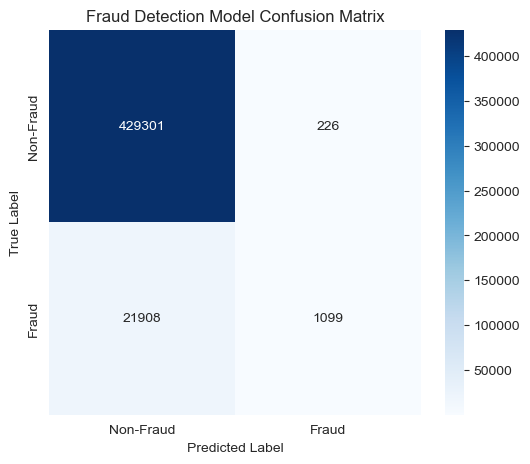

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud", "Fraud"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fraud Detection Model Confusion Matrix")
plt.savefig("../images/confusion_matrix.png", dpi=300)  # Save the image
plt.show()

In [8]:
clean_data = pd.read_csv("../data/final_data_cleaned.csv")

synthetic_data = pd.read_csv("../data/final_data_with_synthetic.csv")

synthetic_data_filtered = synthetic_data.drop_duplicates(keep="first")  # only remove exact full-row duplicates

merged_data = pd.concat([clean_data, synthetic_data_filtered], ignore_index=True)

merged_data.head(10)


,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,zip_code,dti,delinq_2yrs,...,job_category_medical,job_category_nursing,job_category_other,job_category_other_engineering,job_category_sales,job_category_software_it,job_category_supervisor,fraud_prediction,loan_stacking_fraud,geo_fraud
0,0.050633,2500,36,0.321262,84.92,10,55000.0,109,0.01924,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
1,0.746835,30000,60,0.530763,777.23,10,90000.0,713,0.02752,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
2,0.113924,5000,36,0.492991,180.69,6,59280.0,490,0.01151,0.0,...,False,False,False,False,False,False,False,NaN,NaN,NaN
3,0.088608,4000,36,0.530763,146.51,10,92000.0,985,0.01774,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
4,0.746835,30000,60,0.421729,731.78,10,57250.0,212,0.02735,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
5,0.127848,5550,36,0.378115,192.45,10,152500.0,461,0.03894,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
6,0.037975,2000,36,0.492991,72.28,4,51000.0,606,0.00340,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
7,0.139241,6000,36,0.321262,203.79,10,65000.0,460,0.03110,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
8,0.113924,5000,36,0.492991,180.69,10,53580.0,327,0.02216,0.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
9,0.139241,6000,36,0.356698,206.44,0,300000.0,68,0.01843,1.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN


In [9]:
# Fill missing fraud labels with 0 (Non-Fraud)
merged_data["fraud_prediction"].fillna(0, inplace=True)
merged_data["loan_stacking_fraud"].fillna(0, inplace=True)
merged_data["geo_fraud"].fillna(0, inplace=True)

# Ensure fraud labels are integers
merged_data["fraud_prediction"] = merged_data["fraud_prediction"].astype(int)
merged_data["loan_stacking_fraud"] = merged_data["loan_stacking_fraud"].astype(int)
merged_data["geo_fraud"] = merged_data["geo_fraud"].astype(int)

shuffled_data = merged_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Save Updated Dataset
shuffled_data.to_csv("../data/merged_fraud_data.csv", index=False)

print("Fixed NaN values in fraud columns and shuffled to balance the Dataset! Dataset is ready for training.")

C:\Users\mingx\AppData\Local\Temp\ipykernel_11304\1681919919.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data["fraud_prediction"].fillna(0, inplace=True)
C:\Users\mingx\AppData\Local\Temp\ipykernel_11304\1681919919.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



Fixed NaN values in fraud columns and shuffled to balance the Dataset! Dataset is ready for training.


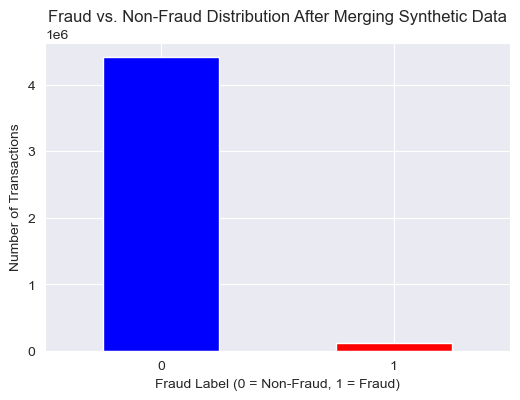

In [10]:
plt.figure(figsize=(6,4))
shuffled_data["fraud_prediction"].value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Fraud vs. Non-Fraud Distribution After Merging Synthetic Data")
plt.xlabel("Fraud Label (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [11]:
merged_data

,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,zip_code,dti,delinq_2yrs,...,job_category_medical,job_category_nursing,job_category_other,job_category_other_engineering,job_category_sales,job_category_software_it,job_category_supervisor,fraud_prediction,loan_stacking_fraud,geo_fraud
0,0.050633,2500,36,0.321262,84.92,10,55000.0,109,0.01924,0.0,...,False,False,True,False,False,False,False,0,0,0
1,0.746835,30000,60,0.530763,777.23,10,90000.0,713,0.02752,0.0,...,False,False,True,False,False,False,False,0,0,0
2,0.113924,5000,36,0.492991,180.69,6,59280.0,490,0.01151,0.0,...,False,False,False,False,False,False,False,0,0,0
3,0.088608,4000,36,0.530763,146.51,10,92000.0,985,0.01774,0.0,...,False,False,True,False,False,False,False,0,0,0
4,0.746835,30000,60,0.421729,731.78,10,57250.0,212,0.02735,0.0,...,False,False,True,False,False,False,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4523331,0.782911,31425,36,0.160826,1005.76,10,15264.0,291,0.04898,0.0,...,False,False,True,False,False,False,False,1,0,0
4523332,0.024051,1450,36,0.000389,43.67,9,65000.0,148,0.02055,0.0,...,False,False,False,False,False,False,False,1,1,0
4523333,0.746835,30000,36,0.087617,934.02,6,250000.0,837,0.01225,0.0,...,False,False,False,False,True,False,False,1,1,0
4523334,0.291139,12000,60,0.454829,298.17,10,34000.0,434,0.05878,0.0,...,False,False,True,False,False,False,False,1,1,0


In [12]:
zip_data = pd.read_csv("../data/uszips.csv")  # Ensure this CSV has columns: zip_code, addr_state

# Extract First 2-3 Digits from ZIP Codes
zip_data["zip_prefix"] = zip_data["zip"].astype(str).apply(lambda x: x[:-3] if len(x) > 3 else x) # Extract first 3 digits

# Drop the Full ZIP Code Column (Optional)
zip_data = zip_data[["zip_prefix", "state_id"]] # Only keep ZIP Prefix & State

zip_data.rename(columns={"state_id": "addr_state_actual"}, inplace=True)
# Save Updated ZIP Code Data
zip_data.to_csv("../data/zip_data_prefix_mapping.csv", index=False)

zip_data

,zip_prefix,addr_state_actual
0,601,PR
1,602,PR
2,603,PR
3,606,PR
4,610,PR
...,...,...
33778,99,AK
33779,99,AK
33780,99,AK
33781,99,AK


In [13]:
# Load Loan Data
merged_data = pd.read_csv("../data/merged_fraud_data.csv")

# Load ZIP Code Mapping Data (Ensuring It Has `zip_prefix` and `addr_state_actual`)
zip_data = pd.read_csv("../data/zip_data_prefix_mapping.csv")

# Convert ZIP Codes to Strings for Proper Matching
merged_data["zip_code"] = merged_data["zip_code"].astype(str)
zip_data["zip_prefix"] = zip_data["zip_prefix"].astype(str)

# Step 1: Extract `addr_state_loan` from One-Hot Encoded Columns
# Find State Columns That Start with "addr_state_"
state_columns = [col for col in merged_data.columns if col.startswith("addr_state_")]

# Function to Extract the State Abbreviation
def get_state_from_one_hot(row):
    for col in state_columns:
        if row[col] == 1:
            return col.replace("addr_state_", "")  # Extract state abbreviation
    return "UNKNOWN"  # If no state found, assign UNKNOWN

# Apply the Function to Extract State
merged_data["addr_state_loan"] = merged_data.apply(get_state_from_one_hot, axis=1)

# Step 2: Merge to Get `addr_state_actual` from ZIP Mapping
zip_mapping = zip_data.set_index("zip_prefix")["addr_state_actual"].to_dict()
merged_data["addr_state_actual"] = merged_data["zip_code"].map(zip_mapping)

In [14]:
merged_data['addr_state_loan']

0          GA
1          FL
2          MD
3          IL
4          MI
           ..
4523331    IN
4523332    MN
4523333    OH
4523334    FL
4523335    AR
Name: addr_state_loan, Length: 4523336, dtype: object

In [15]:
# Load Loan Data
# merged_data = pd.read_csv("../data/merged_fraud_data.csv")

# Load ZIP Code Mapping Data (Keep Only Required Columns)
# zip_data = pd.read_csv("../data/zip_data_prefix_mapping.csv")

# Convert ZIP Codes to Strings for Proper Matching
merged_data["zip_code"] = merged_data["zip_code"].astype(str)
zip_data["zip_prefix"] = zip_data["zip_prefix"].astype(str)

# Reduce Memory Usage by Changing Data Types
merged_data["addr_state_loan"] = merged_data["addr_state_loan"].astype("category")
zip_data["addr_state_actual"] = zip_data["addr_state_actual"].astype("category")

# Create a Dictionary Mapping States to Their ZIP Prefixes
state_to_zip = zip_data.groupby("addr_state_actual")["zip_prefix"].apply(list).to_dict()

# Function to Get a Fraudulent ZIP Code (Belonging to a Different State)
def get_fraudulent_zip(row):
    current_state = row["addr_state_loan"]
    
    # Find a Different State
    other_states = [state for state in state_to_zip.keys() if state != current_state]
    
    if not other_states:  # If no other state found, return original ZIP
        return row["zip_code"]
    
    # Randomly Pick a Different State and Get a Random ZIP from That State
    fraudulent_state = np.random.choice(other_states)
    fraudulent_zip = np.random.choice(state_to_zip[fraudulent_state])
    
    return fraudulent_zip, fraudulent_state

# Select 5% of Data to Modify ZIP Codes for Fraudulent Cases
fraud_sample_size = int(0.05 * len(merged_data))
geo_fraud_indices = np.random.choice(merged_data.index, fraud_sample_size, replace=False)

# Modify ZIP Codes for Fraudulent Entries
for idx in geo_fraud_indices:
    new_zip, new_state = get_fraudulent_zip(merged_data.loc[idx])
    merged_data.at[idx, "zip_code"] = new_zip
    merged_data.at[idx, "addr_state_actual"] = new_state  # Ensure state matches fraudulent ZIP

# Flag These Transactions as Geo Fraud
merged_data["geo_fraud"] = 0  # Default: No fraud
merged_data.loc[geo_fraud_indices, "geo_fraud"] = 1  # Fraudulent ZIP codes

# merged_data = merged_data.drop(coloumns=["addr_state_loan", "addr_state_actual"])

# Save Updated Dataset
merged_data.to_csv("../data/merged_fraud_data_with_geo.csv", index=False)

print(f"Created {fraud_sample_size} geographical fraud cases with randomly mismatched ZIP codes!")


C:\Users\mingx\AppData\Local\Temp\ipykernel_11304\262447955.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_to_zip = zip_data.groupby("addr_state_actual")["zip_prefix"].apply(list).to_dict()


Created 226166 geographical fraud cases with randomly mismatched ZIP codes!


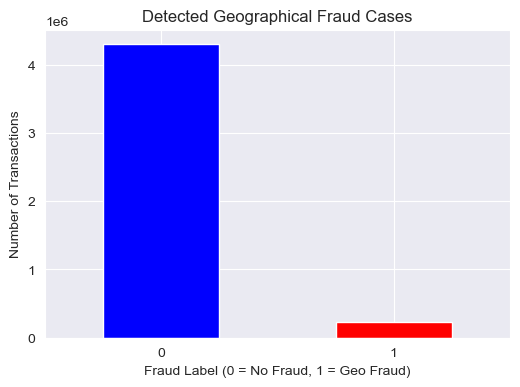

In [16]:
merged_data = pd.read_csv("../data/merged_fraud_data_with_geo.csv")
plt.figure(figsize=(6,4))
merged_data["geo_fraud"].value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Detected Geographical Fraud Cases")
plt.xlabel("Fraud Label (0 = No Fraud, 1 = Geo Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [17]:
merged_data

,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,zip_code,dti,delinq_2yrs,...,job_category_other,job_category_other_engineering,job_category_sales,job_category_software_it,job_category_supervisor,fraud_prediction,loan_stacking_fraud,geo_fraud,addr_state_loan,addr_state_actual
0,0.405063,16500,36,0.089953,514.17,2,91500.00,300,0.01869,0.0,...,True,False,False,False,False,0,1,0,GA,NaN
1,0.088608,4000,36,0.054517,122.98,2,36000.00,331,0.00700,0.0,...,True,False,False,False,False,0,1,0,FL,NaN
2,0.708228,28475,60,0.488707,720.92,0,93000.00,210,0.02750,0.0,...,True,False,False,False,False,0,0,0,MD,NaN
3,0.474051,19225,60,0.338006,447.24,6,46434.72,606,0.01126,0.0,...,True,False,False,False,False,0,0,0,IL,PR
4,0.873418,35000,36,0.218069,1144.37,10,140000.00,486,0.01051,0.0,...,True,False,False,False,False,1,1,0,MI,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4523331,0.113924,5000,36,0.100467,156.43,4,105000.00,462,0.03550,0.0,...,True,False,False,False,False,0,0,0,IN,NaN
4523332,0.873418,35000,60,0.284657,789.57,10,285000.00,560,0.03010,1.0,...,False,False,False,False,False,0,0,0,MN,NaN
4523333,0.341772,14000,60,0.379283,333.43,10,58000.00,455,0.02163,0.0,...,False,False,False,False,True,0,0,0,OH,NaN
4523334,0.240506,10000,36,0.324766,340.08,6,52000.00,349,0.00869,2.0,...,True,False,False,False,False,0,1,0,FL,NaN


In [18]:
# Load Updated Dataset
merged_data = pd.read_csv("../data/merged_fraud_data_with_geo.csv")

merged_data["annual_inc"] = merged_data["annual_inc"].replace(0, 1)

# Calculate Adjusted DTI Ratio (Including New Loan)
merged_data["adjusted_dti"] = (merged_data["dti"] + (merged_data["loan_amnt"] / merged_data["annual_inc"])) * 100  # Convert to percentage

# Replace Any Remaining Inf Values with NaN and Fill with Median
merged_data["adjusted_dti"].replace([np.inf, -np.inf], np.nan, inplace=True)
merged_data["adjusted_dti"].fillna(merged_data["adjusted_dti"].median(), inplace=True)

# Define DTI-Based Fraud and High-Risk Flags
merged_data["dti_fraud"] = merged_data["adjusted_dti"].apply(lambda x: 1 if x > 50 else 0)  # Fraud if DTI > 50%
merged_data["dti_high_risk"] = merged_data["adjusted_dti"].apply(lambda x: 1 if 43 <= x <= 50 else 0)  # Monitor if 43% ≤ DTI ≤ 50%

# Save Updated Dataset
merged_data.to_csv("../data/merged_fraud_data_with_dti.csv", index=False)

print("Implemented DTI fraud detection based on financial risk benchmarks!")


C:\Users\mingx\AppData\Local\Temp\ipykernel_11304\606988624.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data["adjusted_dti"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\mingx\AppData\Local\Temp\ipykernel_11304\606988624.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

Implemented DTI fraud detection based on financial risk benchmarks!


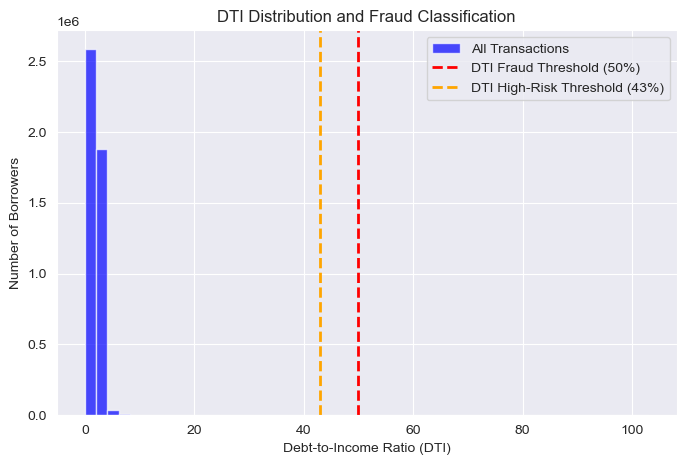

In [19]:
# Plot DTI distribution and fraud classification
merged_data = pd.read_csv("../data/merged_fraud_data_with_dti.csv")

plt.figure(figsize=(8,5))
plt.hist(merged_data["adjusted_dti"], bins=50, color="blue", alpha=0.7, label="All Transactions")
plt.axvline(50, color="red", linestyle="dashed", linewidth=2, label="DTI Fraud Threshold (50%)")
plt.axvline(43, color="orange", linestyle="dashed", linewidth=2, label="DTI High-Risk Threshold (43%)")
plt.legend()
plt.xlabel("Debt-to-Income Ratio (DTI)")
plt.ylabel("Number of Borrowers")
plt.title("DTI Distribution and Fraud Classification")
plt.show()


In [20]:
merged_data

,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,zip_code,dti,delinq_2yrs,...,job_category_software_it,job_category_supervisor,fraud_prediction,loan_stacking_fraud,geo_fraud,addr_state_loan,addr_state_actual,adjusted_dti,dti_fraud,dti_high_risk
0,0.405063,16500,36,0.089953,514.17,2,91500.00,300,0.01869,0.0,...,False,False,0,1,0,GA,NaN,1.869443,0,0
1,0.088608,4000,36,0.054517,122.98,2,36000.00,331,0.00700,0.0,...,False,False,0,1,0,FL,NaN,0.700246,0,0
2,0.708228,28475,60,0.488707,720.92,0,93000.00,210,0.02750,0.0,...,False,False,0,0,0,MD,NaN,2.750762,0,0
3,0.474051,19225,60,0.338006,447.24,6,46434.72,606,0.01126,0.0,...,False,False,0,0,0,IL,PR,1.127021,0,0
4,0.873418,35000,36,0.218069,1144.37,10,140000.00,486,0.01051,0.0,...,False,False,1,1,0,MI,NaN,1.051624,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4523331,0.113924,5000,36,0.100467,156.43,4,105000.00,462,0.03550,0.0,...,False,False,0,0,0,IN,NaN,3.550108,0,0
4523332,0.873418,35000,60,0.284657,789.57,10,285000.00,560,0.03010,1.0,...,False,False,0,0,0,MN,NaN,3.010306,0,0
4523333,0.341772,14000,60,0.379283,333.43,10,58000.00,455,0.02163,0.0,...,False,True,0,0,0,OH,NaN,2.163589,0,0
4523334,0.240506,10000,36,0.324766,340.08,6,52000.00,349,0.00869,2.0,...,False,False,0,1,0,FL,NaN,0.869463,0,0


In [21]:
# Define Chunk Size (Number of Rows Per Chunk)
chunk_size = 50000  # Adjust this based on system memory

# Create an Empty List to Store Processed Chunks
processed_chunks = []

# Process CSV in Chunks
for chunk in pd.read_csv("../data/merged_fraud_data_with_dti.csv", chunksize=chunk_size):
    # Convert Large Integer Columns to int32
    int_columns = chunk.select_dtypes(include=["int64"]).columns
    chunk[int_columns] = chunk[int_columns].astype("int32")

    # Convert Large Float Columns to float32
    float_columns = chunk.select_dtypes(include=["float64"]).columns
    chunk[float_columns] = chunk[float_columns].astype("float32")

    # Store Processed Chunk
    processed_chunks.append(chunk)

# Concatenate All Processed Chunks Into a Final DataFrame
data = pd.concat(processed_chunks, ignore_index=True)

# Save Memory Optimized Dataset
data.to_csv("../data/merged_fraud_data_optimized.csv", index=False)

print("Reduced memory usage by processing dataset in chunks (`int64` → `int32`, `float64` → `float32`).")


Reduced memory usage by processing dataset in chunks (`int64` → `int32`, `float64` → `float32`).


In [22]:
data = pd.read_csv("../data/merged_fraud_data_optimized.csv")

In [23]:
data

,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,zip_code,dti,delinq_2yrs,...,job_category_software_it,job_category_supervisor,fraud_prediction,loan_stacking_fraud,geo_fraud,addr_state_loan,addr_state_actual,adjusted_dti,dti_fraud,dti_high_risk
0,0.405063,16500,36,0.089953,514.17,2,91500.00,300,0.01869,0.0,...,False,False,0,1,0,GA,NaN,1.869443,0,0
1,0.088608,4000,36,0.054517,122.98,2,36000.00,331,0.00700,0.0,...,False,False,0,1,0,FL,NaN,0.700246,0,0
2,0.708228,28475,60,0.488707,720.92,0,93000.00,210,0.02750,0.0,...,False,False,0,0,0,MD,NaN,2.750761,0,0
3,0.474051,19225,60,0.338006,447.24,6,46434.72,606,0.01126,0.0,...,False,False,0,0,0,IL,PR,1.127021,0,0
4,0.873418,35000,36,0.218069,1144.37,10,140000.00,486,0.01051,0.0,...,False,False,1,1,0,MI,NaN,1.051624,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4523331,0.113924,5000,36,0.100467,156.43,4,105000.00,462,0.03550,0.0,...,False,False,0,0,0,IN,NaN,3.550108,0,0
4523332,0.873418,35000,60,0.284657,789.57,10,285000.00,560,0.03010,1.0,...,False,False,0,0,0,MN,NaN,3.010306,0,0
4523333,0.341772,14000,60,0.379283,333.43,10,58000.00,455,0.02163,0.0,...,False,True,0,0,0,OH,NaN,2.163589,0,0
4523334,0.240506,10000,36,0.324766,340.08,6,52000.00,349,0.00869,2.0,...,False,False,0,1,0,FL,NaN,0.869463,0,0


In [24]:
# np.isinf(data).any()

TypeError: ufunc 'isinf' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
data = pd.read_csv("../data/merged_fraud_data_optimized.csv")

data = data.drop(columns=["addr_state_loan", "addr_state_actual"])  # Remove redundant location data


# Fix Loan Stacking Fraud Detection (Using Improved Method)
loan_amt_diff = 100  # Allow small variations in loan amounts ($100 threshold)
data["loan_amnt_rounded"] = (data["loan_amnt"] // loan_amt_diff) * loan_amt_diff  

loan_stacking = data.groupby(["loan_amnt_rounded", "zip_code"]).size().reset_index(name="loan_count")
data = data.merge(loan_stacking, on=["loan_amnt_rounded", "zip_code"], how="left")
data["loan_stacking_fraud"] = data["loan_count"].apply(lambda x: 1 if x > 2 else 0)
data.drop(columns=["loan_count", "loan_amnt_rounded"], inplace=True)

# Step 2: Apply Isolation Forest for Initial Fraud Detection
iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)  # Reduce contamination
iso_forest.fit(data)

# Predict anomalies (-1 = fraud, 1 = normal)
data["fraud_prediction"] = iso_forest.predict(data)
data["fraud_prediction"] = data["fraud_prediction"].apply(lambda x: 1 if x == -1 else 0)  # Convert to 0/1

# Step 3: Prepare Features & Labels
# data = data.drop(columns=["addr_state_loan", "addr_state_actual"])  # Remove redundant location data

y = data["fraud_prediction"]
X = data.drop(columns=["fraud_prediction"])

# Normalize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "../models/scaler_with_fraud_data.pkl")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Step 4: Apply SMOTE (Only if fraud cases are < 10%)
fraud_ratio = y_train.mean()
if fraud_ratio < 0.1:
    smote = SMOTE(sampling_strategy=0.3, random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Step 5: Compute Class Weights
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

# Step 6: Define Focal Loss Function (With Class Weights)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == "mean":
            return F_loss.mean()
        elif self.reduction == "sum":
            return F_loss.sum()
        else:
            return F_loss

# Step 7: Define Improved Neural Network
class FraudDetectionModel(nn.Module):
    def __init__(self, input_size):
        super(FraudDetectionModel, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.layer2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.layer3 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.layer1(x)))
        x = torch.relu(self.bn2(self.layer2(x)))
        x = torch.relu(self.layer3(x))
        x = self.output(x)  # No sigmoid here (Handled in loss function)
        return x

# Initialize Model
input_size = X_train.shape[1]
model = FraudDetectionModel(input_size)

# Define Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define Loss Function
criterion = FocalLoss(alpha=class_weights[1].item() * 2, gamma=2.0)

# Step 8: Train Model
epochs = 100  # Increase epochs for better learning

for epoch in range(epochs):
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor)  # Raw logits (no sigmoid applied)
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_probs = torch.sigmoid(test_outputs)
            test_preds = (test_probs > 0.9).float()  # Apply threshold

            test_fraud_count = test_preds.sum().item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Detected Fraud Cases: {test_fraud_count}")

print("Model Training Completed!")


In [15]:
# Save Model
torch.save(model.state_dict(), "../models/fraud_detection_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [16]:
# Evaluate Model
y_pred = model(X_test_tensor).detach().numpy()
y_pred = (y_pred > 0.5).astype(int)

# Print Evaluation Metrics
print("Model Evaluation Report (After Retraining):")
print(classification_report(y_test, y_pred))

# Print Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Print Precision, Recall, F1-score
precision = precision_score(y_test, y_pred, zero_division=1)
recall = recall_score(y_test, y_pred, zero_division=1)
f1 = f1_score(y_test, y_pred, zero_division=1)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Load Model for Future Use
model = FraudDetectionModel(input_size)
model.load_state_dict(torch.load("../models/fraud_detection_model.pth"))
model.eval()
print("Model loaded successfully for future predictions!")

Model Evaluation Report (After Retraining):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    886575
           1       0.53      0.89      0.67     18093

    accuracy                           0.98    904668
   macro avg       0.77      0.93      0.83    904668
weighted avg       0.99      0.98      0.98    904668

Model Accuracy: 0.9822
Precision: 0.5327
Recall: 0.8858
F1-score: 0.6653
Model loaded successfully for future predictions!


C:\Users\mingx\AppData\Local\Temp\ipykernel_23292\2574816498.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../models/fraud_detection

In [17]:
unique, counts = np.unique(y_pred, return_counts=True)
print("Unique Predictions:", dict(zip(unique, counts)))

Unique Predictions: {np.int64(0): np.int64(874584), np.int64(1): np.int64(30084)}


In [18]:
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class Distribution in Training Data:", class_distribution)

Class Distribution in Training Data: {np.int64(0): np.int64(3546294), np.int64(1): np.int64(1063888)}


In [19]:
y_pred = model(X_test_tensor).detach().numpy()
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

# Count Unique Predictions
unique, counts = np.unique(y_pred, return_counts=True)
print("Unique Predictions:", dict(zip(unique, counts)))

Unique Predictions: {np.int64(0): np.int64(874584), np.int64(1): np.int64(30084)}
